# Boxplots
Boxplots allow viewing basic properties of distributions, including medians and variation. For categorical-to-continuous distributions, we can create a set of boxplots and quickly see how the median and variation change across values of the categorical value.

Let's take a look!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load penguins data
penguins = sns.load_dataset('penguins')
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


`sns.catplot()` is the figure-level function in Seaborn to create boxplots. You can specify a categorical variable on the x-axis to view multiple boxplots for the continuous variable across values of that categorical variable.

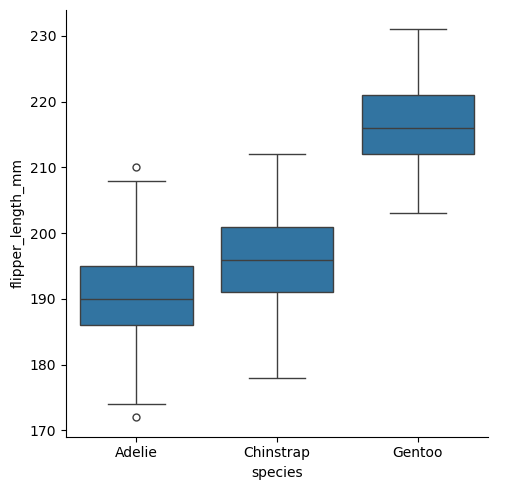

In [4]:
sns.catplot(data=penguins, x='species', y='flipper_length_mm', kind='box')
plt.show()

How can we interpret boxplots? What does each element show?

Here's a diagram of a horizontal boxplot:

<img src="attachment:521c9bbe-bf34-44bd-a8ea-fbbfa4c9d096.png"/>

*Image from OpenClipart*

The line on the box shows the median of the data, the middle value with equal numbers of higher datapoints and lower datapoints around it.

The box shows where the middle 50% of the data is, from 25% to 75% of the data's values of a continuous variable. To put it another way: If you divided the data into *quartiles*, 4 ranges with equal numbers of datapoints, the box shows quartile 1 (Q1) to quartile 3 (Q3). This range of this middle 50% is called the "interquartile range" (IQR). The "whiskers", lines outside of the box, extend to the minimum and maximum values of the data, as long as those values are within 1.5 times the IQR from the box. If any datapoints are outside 1.5 times the IQR from the box, they show up as individual datapoints in the boxplot. These can be considered outliers, very far from the median.

Boxplots enable a quick visualization of the median and spread of the data by how long the box and whiskers are.

Note that the data does not have to from a Gaussian distribution like in the diagram. Any distribution can be visualized with a boxplot.

You can also show mean values on the boxes by passing `showmeans=True` to `sns.catplot()`.

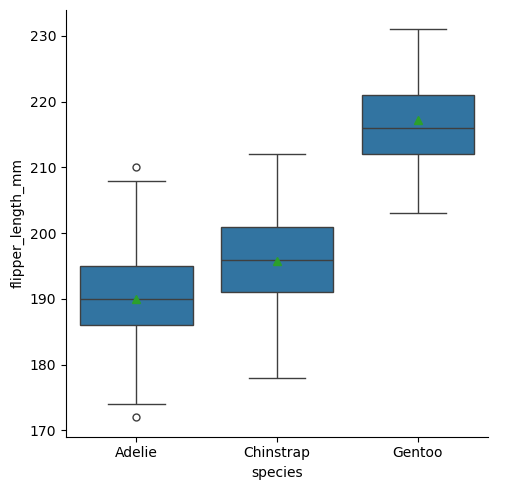

In [5]:
sns.catplot(data=penguins, x='species', y='flipper_length_mm', kind='box', showmeans=True)
plt.show()

## Boxplots are not effective for skewed distributions
Boxplots are best when distributions are roughly symmetric, that is, have most values near the middle of the range.

Distributions with many values at either end of a range (not symmetric) are *skewed*. Let's load an examine a skewed distribution.

In [6]:
diamonds = sns.load_dataset('diamonds')
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


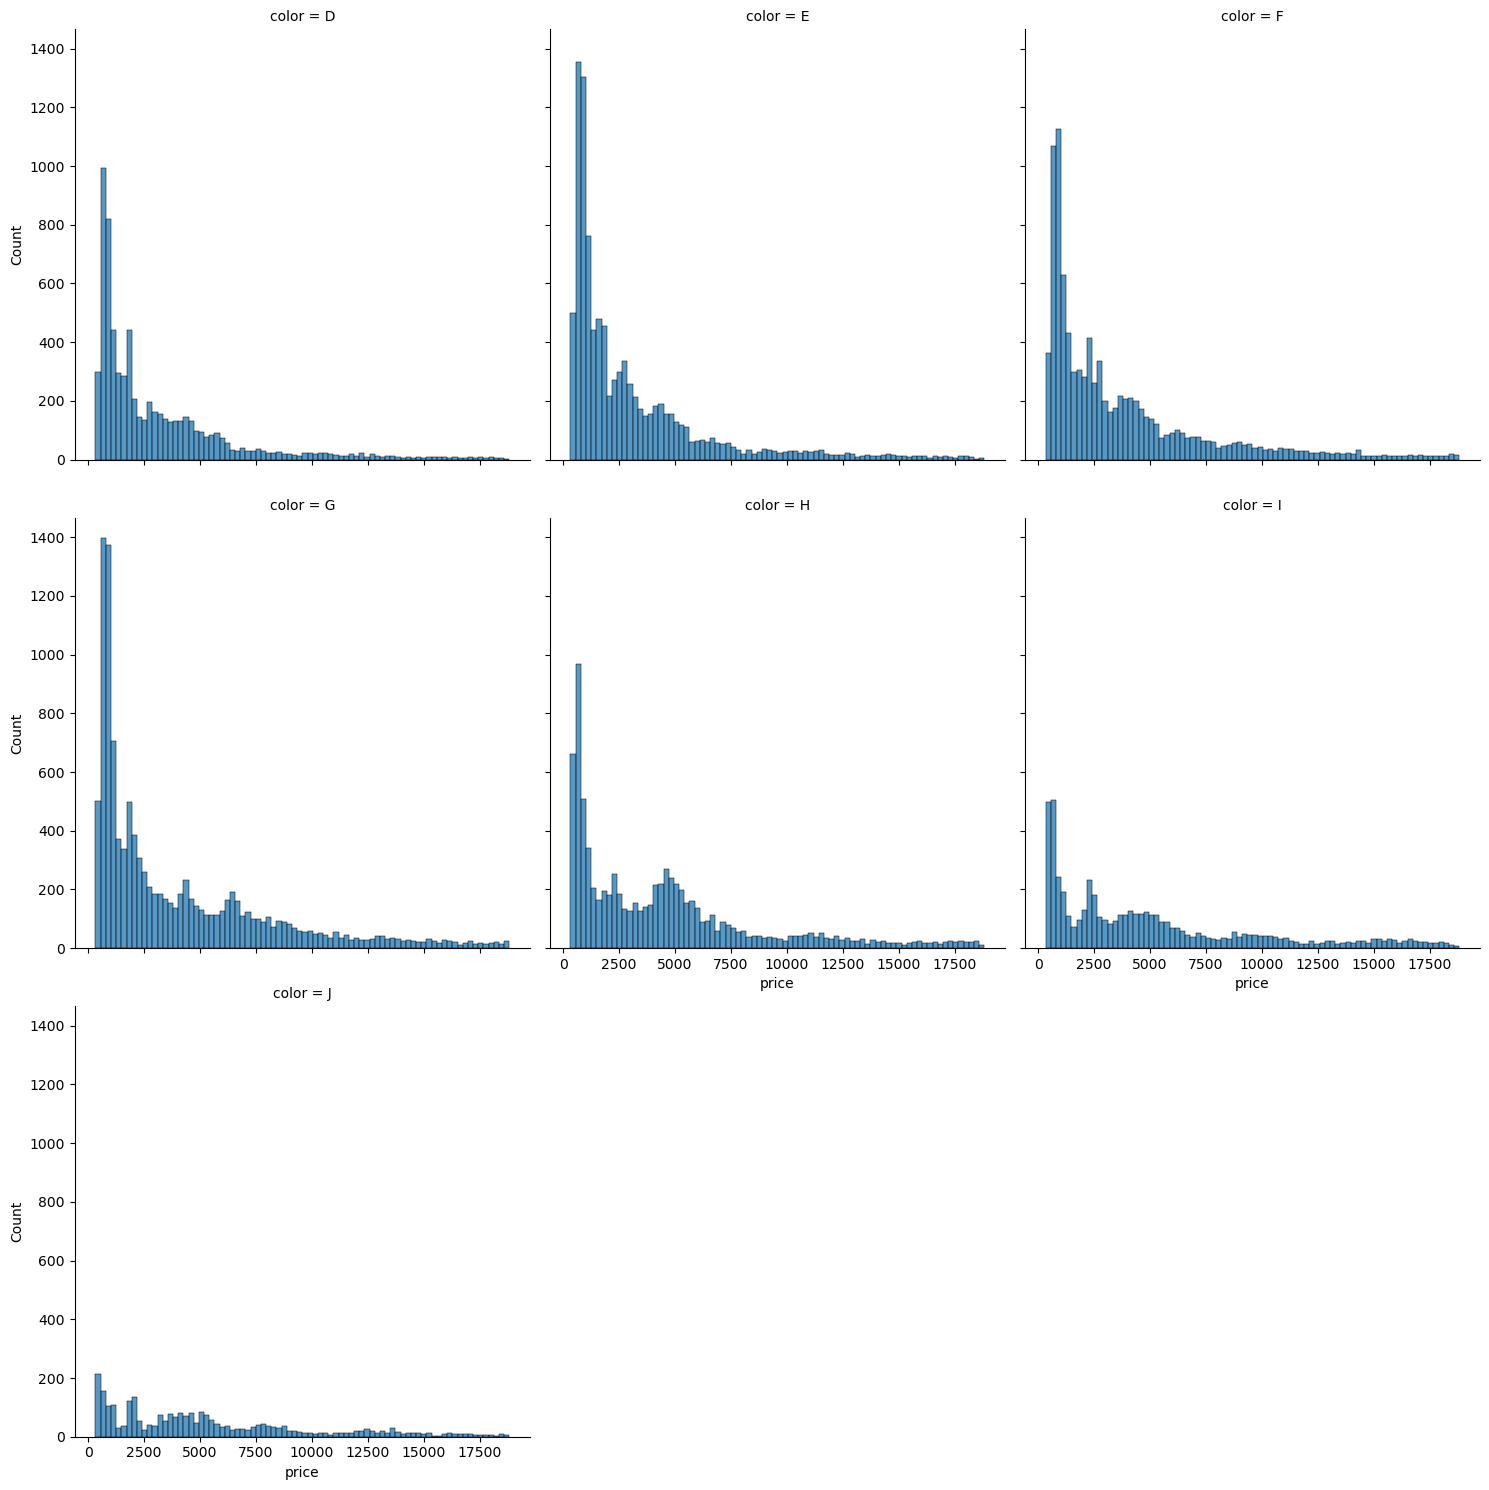

In [7]:
sns.displot(data=diamonds, x='price', col='color', kind='hist', col_wrap=3)
plt.show()

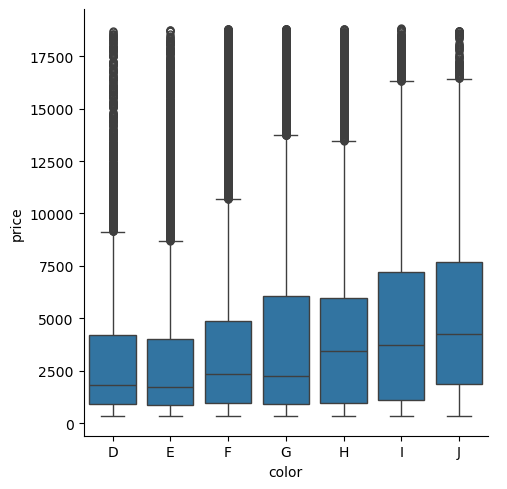

In [8]:
sns.catplot(data=diamonds, x='color', y='price', kind='box')
plt.show()

Look at all those outliers! Boxplots are not useful for skewed distributions. Instead, if you are comparing skewed continuous distributions across categories, consider faceted histograms or conditional KDE plots.

In [9]:
ct = pd.crosstab(diamonds["color"], diamonds["price"])
sns.heatmap(ct, annot=True)


<Axes: xlabel='price', ylabel='color'>

Error in callback <function flush_figures at 0x000001505244EFC0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 